Dataset shape: (550502, 18)

Column dtypes:
 chef_count                       int64
efficiency_score               float64
item_complexity_score          float64
weather                          int64
festival_flag                    int64
weekend                          int64
prep_time                      float64
chef_load_ratio                float64
queue_per_chef                 float64
restaurant_avg_prep_time       float64
prep_time_recent_avg           float64
complexity_load_interaction    float64
hour_sin                       float64
hour_cos                       float64
dow_sin                        float64
dow_cos                        float64
log_queue_length               float64
cuisine_encoded                float64
dtype: object

NaN counts before cleaning:
prep_time_recent_avg    1
dtype: int64

NaN counts after cleaning: 0 remaining

Target (prep_time) stats:
 count    550502.000000
mean         23.631440
std          10.210106
min           5.000000
25%        

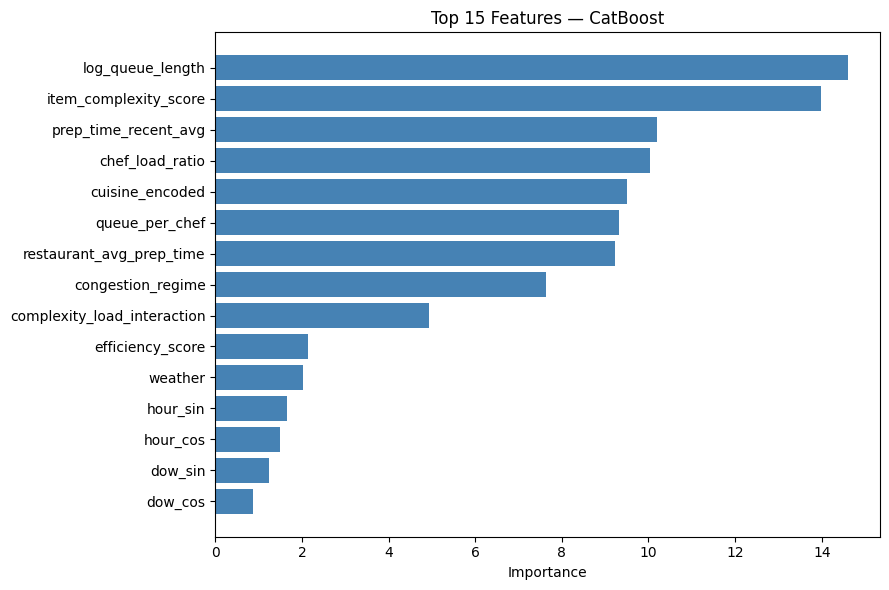

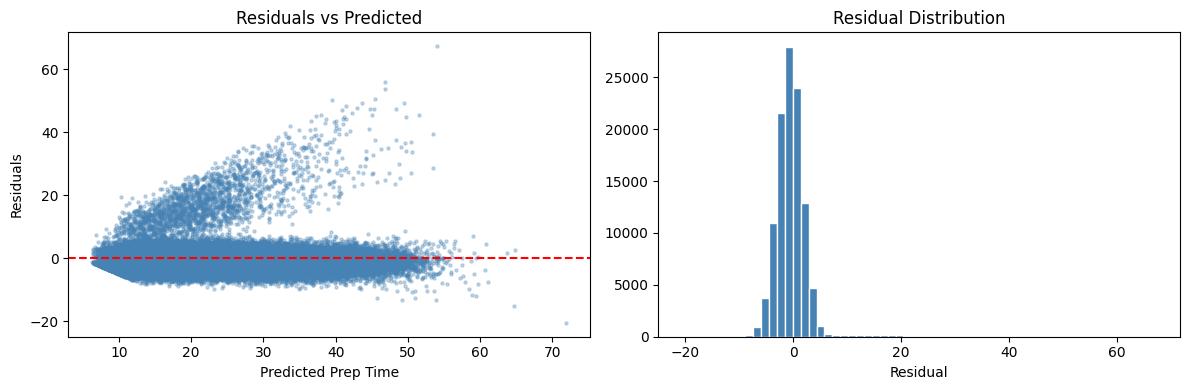

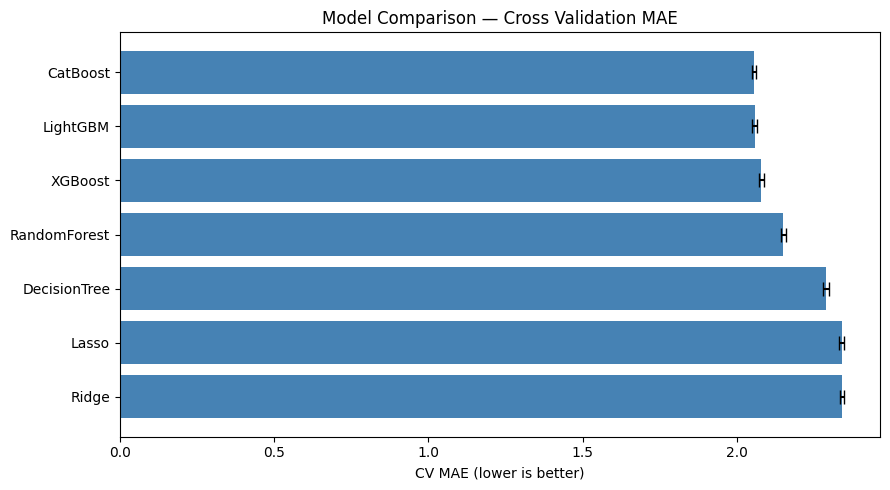


✅ Model saved as: best_model_CatBoost.pkl


In [3]:
# ==========================================
# THREAD CONFIG — MUST BE FIRST (M4 Mac fix)
# ==========================================

import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"

# ==========================================
# IMPORTS
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("/Users/sherry/Desktop/HACKATHON/zomato_kpt_final_19_features_Sherry.csv")

print("Dataset shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)

# ==========================================
# NaN HANDLING
# (all columns are numerical — categoricals already encoded)
# ==========================================

print("\nNaN counts before cleaning:")
nan_counts = df.isnull().sum()
print(nan_counts[nan_counts > 0] if nan_counts.sum() > 0 else "None found")

for col in df.columns:
    if col != "prep_time":
        df[col].fillna(df[col].median(), inplace=True)

# Drop rows where target itself is NaN — cannot be imputed
df.dropna(subset=["prep_time"], inplace=True)

print("\nNaN counts after cleaning:", df.isnull().sum().sum(), "remaining")
print("\nTarget (prep_time) stats:\n", df["prep_time"].describe())

# ==========================================
# CONGESTION REGIME FEATURE
# ==========================================

df["congestion_regime"] = pd.cut(
    df["chef_load_ratio"],
    bins=[0, 0.6, 0.85, 1.1, 5],
    labels=[0, 1, 2, 3]
).astype(float).fillna(-1).astype(int)

# ==========================================
# FEATURE / TARGET SPLIT
# ==========================================

X = df.drop(columns=["prep_time"])
y = df["prep_time"]

print(f"\nFeatures ({len(X.columns)}):", list(X.columns))

# ==========================================
# HOLDOUT SPLIT — FINAL 20%
# ==========================================

split_index = int(len(df) * 0.8)

X_train_full = X.iloc[:split_index]
y_train_full = y.iloc[:split_index]

X_holdout    = X.iloc[split_index:]
y_holdout    = y.iloc[split_index:]

print(f"\nTrain size: {len(X_train_full)} | Holdout size: {len(X_holdout)}")

# ==========================================
# MODEL DEFINITIONS
# ==========================================

models = {
    "LightGBM": LGBMRegressor(
        objective="huber",
        n_estimators=1200,
        learning_rate=0.04,
        num_leaves=64,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=1,           # keep at 1 to avoid M4 deadlock
        nthread=1,
        tree_method="hist"
    ),

    "CatBoost": CatBoostRegressor(
        iterations=1200,
        learning_rate=0.04,
        depth=8,
        verbose=0,
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_depth=14,
        n_jobs=-1,
        random_state=42
    ),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=14,
        min_samples_leaf=25,
        random_state=42
    ),

    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001)
}

# ==========================================
# HELPER: SAMPLE WEIGHTS
# ==========================================

def compute_weights(X_df):
    return 1 + (X_df["chef_load_ratio"] ** 2) * 2

BOOSTING_MODELS = ["LightGBM", "XGBoost", "CatBoost"]

# ==========================================
# KFOLD CROSS VALIDATION
# ==========================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("\n================ CROSS VALIDATION (KFold) ================\n")

for name, model in models.items():

    mae_scores, rmse_scores, r2_scores = [], [], []

    print(f"\nModel: {name}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full)):

        X_train = X_train_full.iloc[train_idx]
        X_val   = X_train_full.iloc[val_idx]
        y_train = y_train_full.iloc[train_idx]
        y_val   = y_train_full.iloc[val_idx]

        if name in BOOSTING_MODELS:
            weights = compute_weights(X_train)
            model.fit(X_train, y_train, sample_weight=weights)
        else:
            model.fit(X_train, y_train)

        preds = model.predict(X_val)

        mae  = mean_absolute_error(y_val, preds)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        r2   = r2_score(y_val, preds)

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        r2_scores.append(r2)

        print(f"  Fold {fold+1} → MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.4f}")

    print(f"  >> Mean MAE: {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")

    results.append({
        "Model":        name,
        "CV_MAE_Mean":  np.mean(mae_scores),
        "CV_MAE_Std":   np.std(mae_scores),
        "CV_RMSE_Mean": np.mean(rmse_scores),
        "CV_R2_Mean":   np.mean(r2_scores)
    })

# ==========================================
# MODEL RANKING
# ==========================================

results_df = pd.DataFrame(results).sort_values(by="CV_MAE_Mean").reset_index(drop=True)

print("\n================ MODEL RANKING ================\n")
print(results_df.to_string(index=False))

best_row        = results_df.iloc[0]
best_model_name = best_row["Model"]
best_model      = models[best_model_name]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   CV MAE : {best_row['CV_MAE_Mean']:.4f} ± {best_row['CV_MAE_Std']:.4f}")

# ==========================================
# RETRAIN BEST MODEL ON FULL TRAINING SET
# ==========================================

full_weights = compute_weights(X_train_full)

if best_model_name in BOOSTING_MODELS:
    best_model.fit(X_train_full, y_train_full, sample_weight=full_weights)
else:
    best_model.fit(X_train_full, y_train_full)

# ==========================================
# HOLDOUT EVALUATION
# ==========================================

holdout_preds = best_model.predict(X_holdout)

mae  = mean_absolute_error(y_holdout, holdout_preds)
rmse = np.sqrt(mean_squared_error(y_holdout, holdout_preds))
r2   = r2_score(y_holdout, holdout_preds)

print("\n================ FINAL HOLDOUT PERFORMANCE ================\n")
print(f"Model : {best_model_name}")
print(f"MAE   : {mae:.3f}")
print(f"RMSE  : {rmse:.3f}")
print(f"R²    : {r2:.4f}")

# ==========================================
# CONGESTION-SPECIFIC EVALUATION
# ==========================================

df_holdout               = df.iloc[split_index:].copy()
df_holdout["prediction"] = holdout_preds

mask_cong   = df_holdout["chef_load_ratio"] > 0.8
mask_normal = ~mask_cong

mae_cong   = mean_absolute_error(df_holdout[mask_cong]["prep_time"],   df_holdout[mask_cong]["prediction"])
mae_normal = mean_absolute_error(df_holdout[mask_normal]["prep_time"], df_holdout[mask_normal]["prediction"])

print(f"\nMAE During High Load  (chef_load_ratio > 0.8) : {mae_cong:.3f}")
print(f"MAE During Normal Load                         : {mae_normal:.3f}")

print("\nMAE by Congestion Regime:")
for regime in sorted(df_holdout["congestion_regime"].unique()):
    mask = df_holdout["congestion_regime"] == regime
    if mask.sum() > 0:
        r_mae = mean_absolute_error(df_holdout[mask]["prep_time"], df_holdout[mask]["prediction"])
        print(f"  Regime {regime}: MAE = {r_mae:.3f}  (n={mask.sum()})")

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

if hasattr(best_model, "feature_importances_"):

    importances = pd.DataFrame({
        "feature":    X.columns,
        "importance": best_model.feature_importances_
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

    print("\nTop 15 Important Features:\n")
    print(importances.head(15).to_string(index=False))

    plt.figure(figsize=(9, 6))
    plt.barh(importances["feature"][:15][::-1], importances["importance"][:15][::-1], color="steelblue")
    plt.xlabel("Importance")
    plt.title(f"Top 15 Features — {best_model_name}")
    plt.tight_layout()
    plt.show()

# ==========================================
# RESIDUAL ANALYSIS
# ==========================================

residuals = y_holdout.values - holdout_preds

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(holdout_preds, residuals, alpha=0.3, s=5, color="steelblue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Prep Time")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=60, color="steelblue", edgecolor="white")
plt.xlabel("Residual")
plt.title("Residual Distribution")

plt.tight_layout()
plt.show()

# ==========================================
# CV COMPARISON CHART
# ==========================================

plt.figure(figsize=(9, 5))
plt.barh(results_df["Model"][::-1], results_df["CV_MAE_Mean"][::-1],
         xerr=results_df["CV_MAE_Std"][::-1], color="steelblue", capsize=5)
plt.xlabel("CV MAE (lower is better)")
plt.title("Model Comparison — Cross Validation MAE")
plt.tight_layout()
plt.show()

# ==========================================
# SAVE BEST MODEL
# ==========================================

model_filename = f"best_model_{best_model_name}.pkl"
joblib.dump(best_model, model_filename)
print(f"\n✅ Model saved as: {model_filename}")